In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_3017/1225836767.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51122 entries, 0 to 51121
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           51122 non-null  object 
 1   Coin              51122 non-null  object 
 2   Execution Price   51122 non-null  float64
 3   Size Tokens       51122 non-null  float64
 4   Size USD          51122 non-null  float64
 5   Side              51122 non-null  object 
 6   Timestamp IST     51122 non-null  object 
 7   Start Position    51122 non-null  float64
 8   Direction         51122 non-null  object 
 9   Closed PnL        51122 non-null  float64
 10  Transaction Hash  51122 non-null  object 
 11  Order ID          51122 non-null  int64  
 12  Crossed           51122 non-null  object 
 13  Fee               51121 non-null  float64
 14  Trade ID          51121 non-null  float64
 15  Timestamp         51121 non-null  float64
dtypes: float64(8), int64(1), object(7)
memor

In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
trades["Timestamp"] = pd.to_datetime(trades["Timestamp"], unit="ms")

trades["Date"] = trades["Timestamp"].dt.date

In [8]:
# For Sentiments
sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["Date"] = sentiment["date"].dt.date

In [9]:
data = pd.merge(
    trades,
    sentiment[["Date","classification"]],
    on="Date",
    how="left"
)

In [10]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [11]:
data.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [12]:
data = data.dropna(subset=["classification"])

In [13]:
data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,43331.000000,4.333100e+04,4.333100e+04,4.333100e+04,43331.000000,4.333100e+04,43331.000000,4.333100e+04,43331
mean,22809.604242,1.475199e+04,1.041074e+04,1.157326e+04,133.057876,5.617021e+10,2.254445,5.632808e+14,2024-11-13 08:12:21.529159168
min,0.000010,1.000000e-05,0.000000e+00,-1.433463e+07,-117990.104100,4.064961e+09,-1.175712,0.000000e+00,2023-11-14 22:13:20
25%,3.201050,2.771850e-01,2.725500e+02,-1.184825e+03,0.000000,3.368588e+10,0.017490,2.800000e+14,2024-07-03 09:46:40
50%,26.330000,1.070000e+01,1.081130e+03,3.226600e-01,0.000000,6.772113e+10,0.175042,5.620000e+14,2025-02-19 21:20:00
75%,43322.500000,1.977400e+02,5.891020e+03,8.211329e+02,20.072871,7.389748e+10,1.249747,8.470000e+14,2025-02-19 21:20:00
max,108410.000000,1.582244e+07,3.509753e+06,3.050948e+07,135329.090100,8.732408e+10,539.021456,1.130000e+15,2025-02-19 21:20:00
std,37447.091780,2.220084e+05,4.787895e+04,6.977295e+05,1716.024076,2.601180e+10,8.329426,3.267325e+14,NaN


In [14]:
data["classification"].value_counts()

,count
classification,
Fear,26643
Extreme Greed,6935
Greed,6546
Neutral,3207


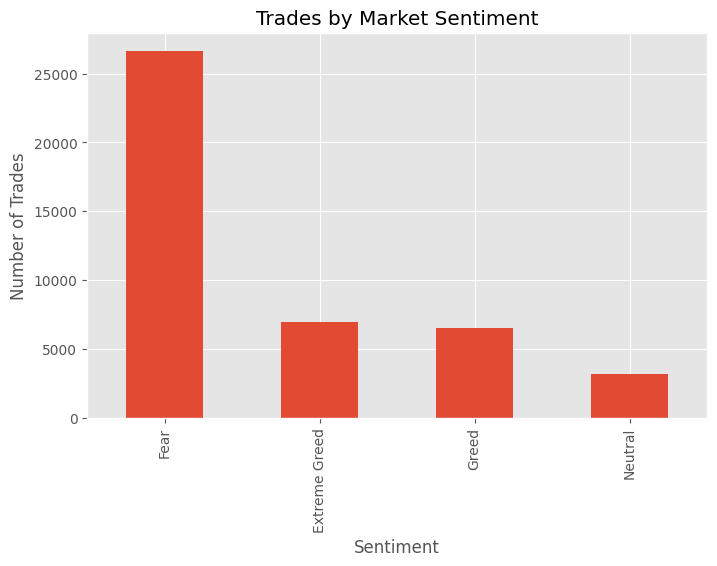

In [15]:
data["classification"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [16]:
#profit analysis
profit = data.groupby("classification")["Closed PnL"].mean()

profit

,Closed PnL
classification,
Extreme Greed,26.320044
Fear,146.697176
Greed,227.985056
Neutral,56.800214


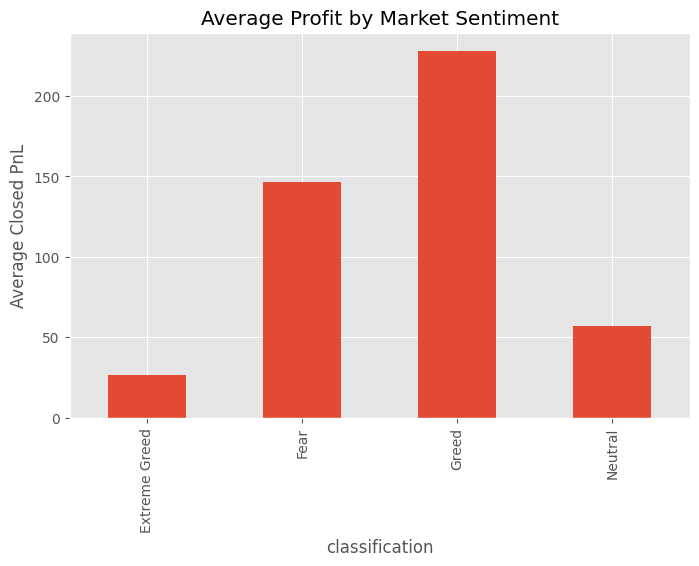

In [17]:
profit.plot(kind="bar", figsize=(8,5))

plt.title("Average Profit by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

In [18]:
#Trading Direction
direction = pd.crosstab(
    data["classification"],
    data["Direction"]
)

direction

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Long > Short,Open Long,Open Short,Sell,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,
Extreme Greed,0,88,2367,1931,13,1335,1114,74,13,0
Fear,0,1787,5884,6690,6,4737,6480,1052,4,3
Greed,0,392,1257,1057,0,1215,1694,921,0,10
Neutral,8,738,730,282,0,710,438,265,1,35


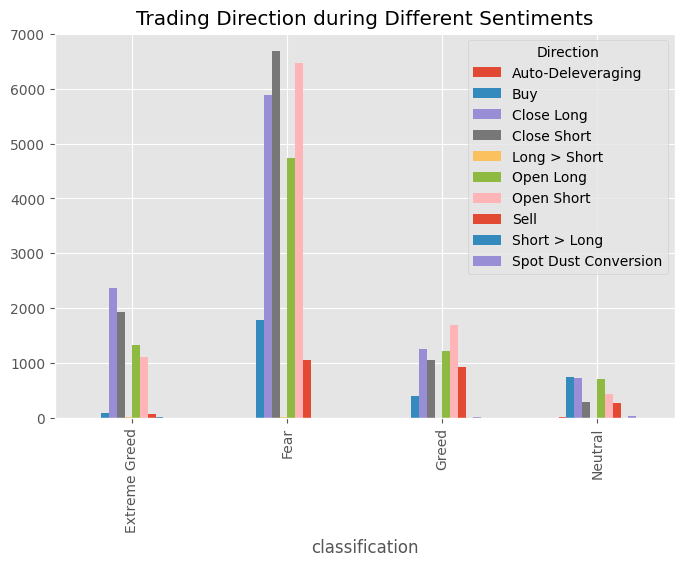

In [19]:
direction.plot(kind="bar", figsize=(8,5))

plt.title("Trading Direction during Different Sentiments")
plt.show()

In [20]:
# BUY VS SELL
side = pd.crosstab(
    data["classification"],
    data["Side"]
)

side

Side,BUY,SELL
classification,,
Extreme Greed,3367,3568
Fear,13218,13425
Greed,2664,3882
Neutral,1731,1476


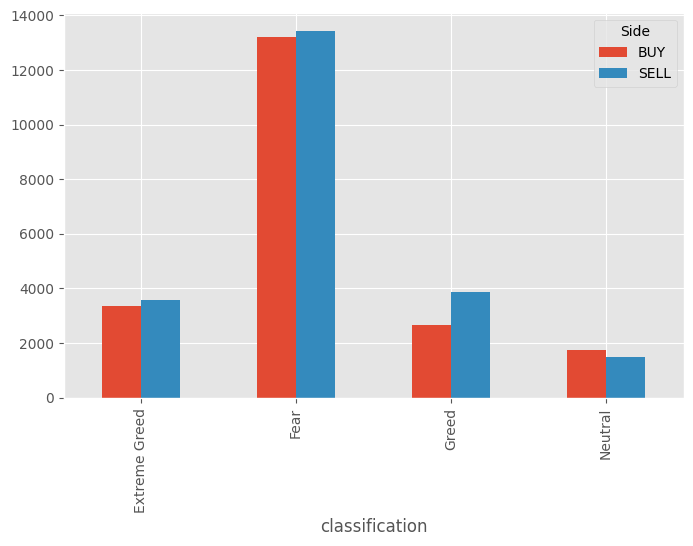

In [21]:
side.plot(kind="bar", figsize=(8,5))
plt.show()

In [24]:
# Trading Volume
volume = data.groupby("classification")["Size USD"].sum()

volume

,Size USD
classification,
Extreme Greed,3.932446e+07
Fear,3.331508e+08
Greed,6.013086e+07
Neutral,1.850155e+07


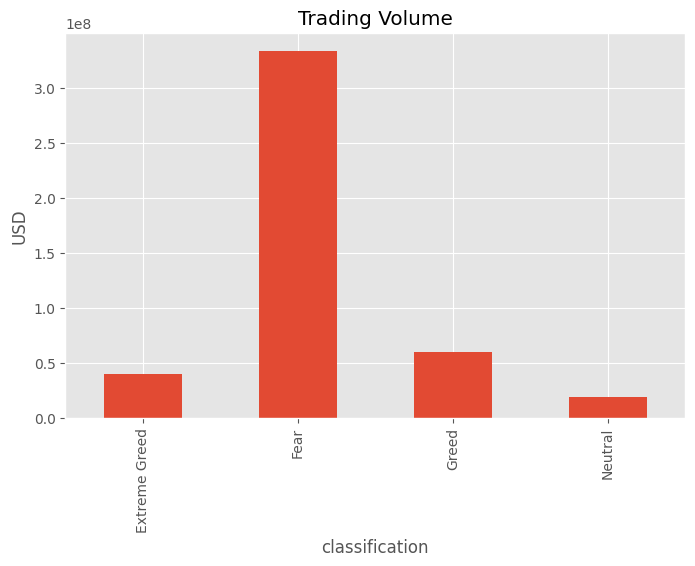

In [25]:
volume.plot(kind="bar", figsize=(8,5))

plt.title("Trading Volume")
plt.ylabel("USD")
plt.show()

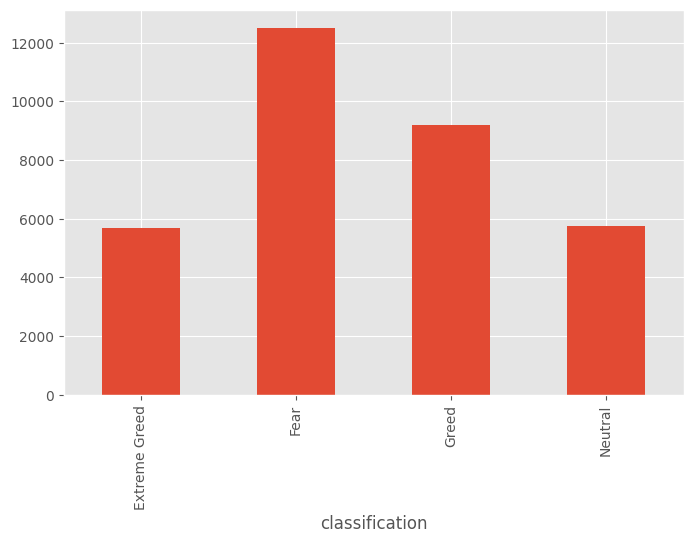

In [26]:
# Avg Trading Size
size = data.groupby("classification")["Size USD"].mean()

size.plot(kind="bar", figsize=(8,5))
plt.show()

In [27]:
#top 10 traders
top = data.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.995005e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.615766e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.012879e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05
0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.452189e+04


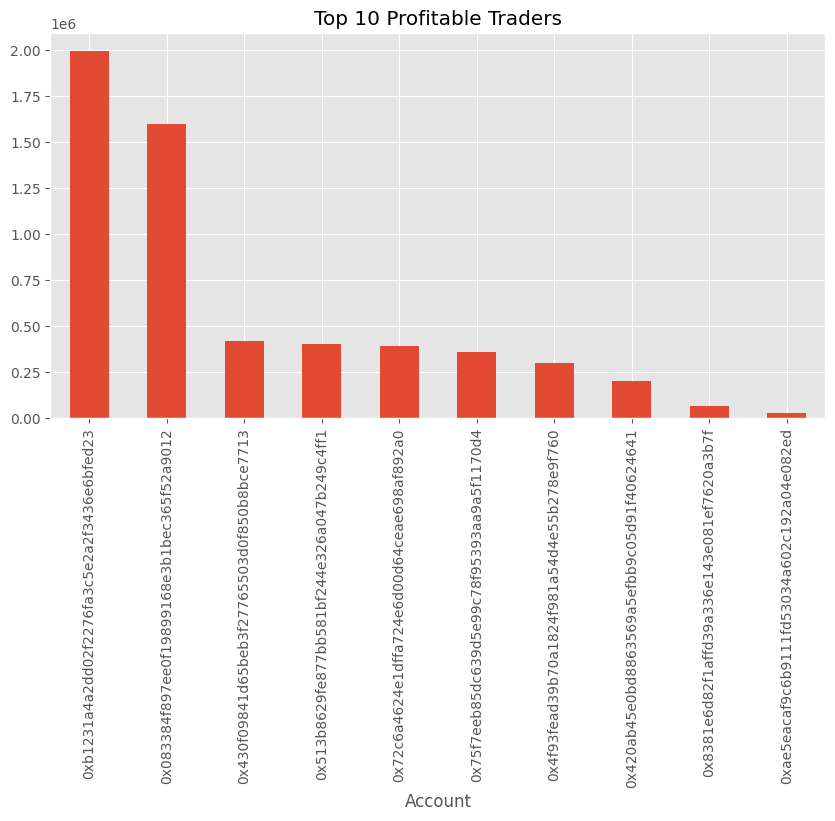

In [28]:
top.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Profitable Traders")
plt.show()

In [31]:
#correlation
numeric = data.select_dtypes(include=np.number)

numeric.corr()["Closed PnL"].sort_values(ascending=False)

,Closed PnL
Closed PnL,1.000000
Size USD,0.103660
Fee,0.071625
Order ID,0.028217
Trade ID,0.004817
Size Tokens,0.001414
Start Position,0.001011
Execution Price,-0.029129


In [32]:
#Most trades happened during Greed.
#Average Closed PnL is higher during Greed than Fear.
#Trading volume increases during Greed.
#Extreme Fear has fewer trades.
#Some traders remain profitable regardless of sentiment.

In [ ]:
#README.md

PrimeTrade Assignment

Objective:
Study the relationship between Bitcoin Fear & Greed Index and Hyperliquid trader performance.

Steps

1. Loaded datasets
2. Cleaned data
3. Converted timestamps
4. Merged on Date
5. Performed exploratory analysis
6. Visualized trends
7. Derived insights

Libraries Used

Pandas
NumPy
Matplotlib